In [1]:
import sys, os
import numpy as np
import matplotlib.pyplot as plt
from   pathlib import Path
import time

import gdsfactory as gf
# gf.gpdk.PDK.activate()

total_start = time.time()

# ----------------------------------------------------------------------------------
# Lumerical API path (uncomment for your machine) 
# ----------------------------------------------------------------------------------
sys.path.append(r'C:\Program Files\ANSYS Inc\v251\Lumerical\api\python')  # QP5

# ----------------------------------------------------------------------------------
# Paths
# ----------------------------------------------------------------------------------
WorkDir   = Path().resolve()       # D:\...\scripts\directional_coupler
REPO_ROOT = WorkDir.parents[1]     # D:\Ligentic_NU_1_TapeOut_April2026
os.chdir(WorkDir)

DataDir = WorkDir / "FDTD_Results"
DataDir.mkdir(parents=True, exist_ok=True)

print("Working dir :", WorkDir)
print("Data save   :", DataDir)

Working dir : D:\Ligentic_NU_1_TapeOut_April2026\scripts
Data save   : D:\Ligentic_NU_1_TapeOut_April2026\scripts\FDTD_Results


In [2]:
#------------------------------------------------------------
# LUMERICAL SESSION
#------------------------------------------------------------
import lumapi as lm

f = lm.MODE()

LumFileName = "Test_AFQH_GDS.lms"
LumFilePath = str(WorkDir / LumFileName)
f.save(LumFilePath)

f.switchtolayout()
f.selectall()
f.delete()

C:\Program Files\ANSYS Inc\v251\Lumerical\api\python\lumapi.py:895: SyntaxWarning: invalid escape sequence '\s'
  message = re.sub('^(Error:)\s(prompt line)\s[0-9]+:', '', str(rvals[2])).strip()


Min: (0.00, -719.60) µm
Max: (1000.00, 0.60) µm
Center: (500.00, -359.50) µm
Span: 1000.00 x 720.20 µm
Frequency Points: 3000


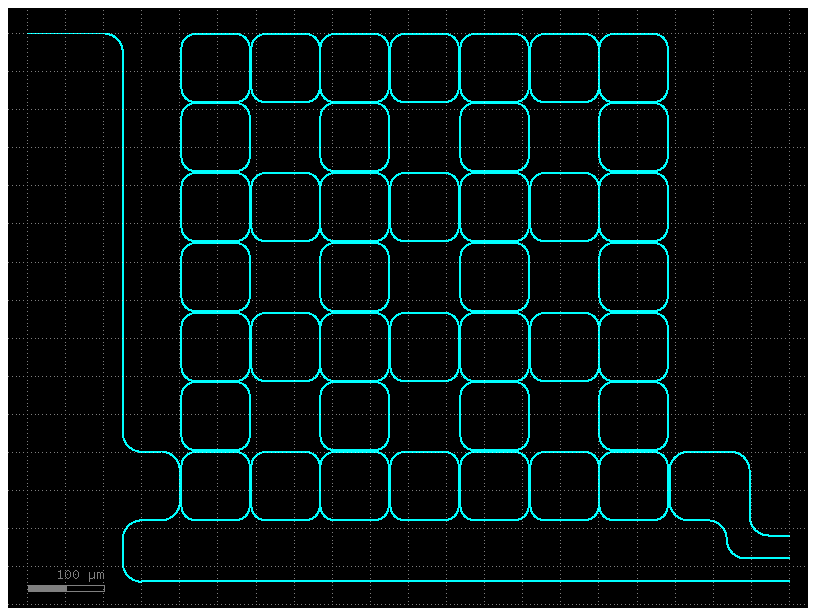

In [3]:
#------------------------------------------------------------
# GEOMETRY SETUP (LOAD EXISTING)
#------------------------------------------------------------
gf.clear_cache()

gds_path = str(WorkDir / "Test_AFQH_7x7_L_40_Gap_300_FCGap_650nm.gds")
device   = gf.import_gds(gds_path)

# Extract the bounding box
bbox = device.bbox()

xmin, ymin = bbox.left, bbox.bottom
xmax, ymax = bbox.right, bbox.top
center_x   = (xmin + xmax) / 2.0
center_y   = (ymin + ymax) / 2.0
span_x     = xmax - xmin
span_y     = ymax - ymin

# Verification
print(f"Min: ({xmin:.2f}, {ymin:.2f}) µm")
print(f"Max: ({xmax:.2f}, {ymax:.2f}) µm")
print(f"Center: ({center_x:.2f}, {center_y:.2f}) µm")
print(f"Span: {span_x:.2f} x {span_y:.2f} µm")
# Verify geometry
device.plot()

#------------------------------------------------------------
# PARAMETERS 
#------------------------------------------------------------



XLength        = 100E-6
YLength        = 15E-6

Material           = "Si3N4 (Silicon Nitride) - Luke"
UseIndex           = True
Index              = 1.97        # optional, used if material = '<Object defined dielectric>'
BackgroundMaterial = "SiO2 (Glass) - Palik"
SimulationTime     = 100E-12
FrequencyPoints    = 3000
decay_rate         = 5E-5

print(f"Frequency Points: {FrequencyPoints}")







In [4]:
f.switchtolayout()
f.selectall()
f.delete()

#------------------------------------------------------------
# GDS load to Lum
#------------------------------------------------------------

Material           = "Si3N4 (Silicon Nitride) - Luke"
UseIndex           = True
Index              = 1.97        # optional, used if material = '<Object defined dielectric>'
BackgroundMaterial = "SiO2 (Glass) - Palik"
Height             = 800E-9

device.write_gds(gds_path)
f.gdsimport(gds_path, device.name, "2:0", Material, 0, Height)

if UseIndex:
    f.set("material", "<Object defined dielectric>")
    f.set("index", Index)

LambdaStart    = 1545E-9
LambdaStop     = 1553E-9

#------------------------------------------------------------
# Parameters (from gds)
#------------------------------------------------------------
Nx           = 7
Ny           = 7
Gap          = 300E-9
FCGap        = 700E-9
Lc           = 40.0E-6
WgWidth      = 1.2E-6
Radius       = 25E-6
BendRadiusIO = 25E-6

BendRadius   = Radius
LengthRing   = Lc



LatticeLengthX = Nx*(LengthRing + 2*BendRadius) + (Nx-1)*(Gap + WgWidth)
LatticeLengthY = Ny*(LengthRing + 2*BendRadius) + (Ny-1)*(Gap + WgWidth)

InLengthX      = 200E-6 
InLengthY      = LatticeLengthY - (BendRadius + LengthRing/2)

Margin  = 10E-6

xmin    =  InLengthX - 1.5*BendRadiusIO - Margin
ymin    = -LatticeLengthY - Margin

SimXSpan = LatticeLengthX + 2*(FCGap+WgWidth) + 3*BendRadiusIO + 2*Margin
SimYSpan = LatticeLengthY + 2*Margin

x0     = -SimXSpan/2 + (1.5*BendRadiusIO + Margin) +  (WgWidth + FCGap) + BendRadius + LengthRing/2
y0     = -SimYSpan/2 + Margin

SourcePosX =  InLengthX - BendRadiusIO - 0.5*Margin
SourcePosY =  -InLengthY + LengthRing/2 + BendRadiusIO 

TH_PosX    =  SourcePosX
TH_PosY    =  SourcePosY - LengthRing - 2*BendRadius

DR_PosX    =  InLengthX + 2*(FCGap + WgWidth) + LatticeLengthX + BendRadiusIO + 0.5*Margin
DR_PosY    =  SourcePosY

tag      = f"Test_AFQH_7x7_FCGap_{FCGap*1e9:.0f}nm_Rings_R{Radius*1e6:.0f}um_W{WgWidth*1e9:.0f}nm_Gap{Gap*1e9:.0f}nm_Lc{Lc*1e6:.0f}um_decay{decay_rate:.0e}"
fname    = DataDir / f"{tag}.txt"
print(f"Data file: {fname}")


#------------------------------------------------------------
# varFDTD
#------------------------------------------------------------
f.addvarfdtd()
f.set("simulation time", SimulationTime)
f.set("x0", x0)
f.set("y0", y0)
f.set("x min", xmin)
f.set("y min", ymin)
f.set("x max", xmin+SimXSpan)
f.set("y max", ymin+SimYSpan)
f.set("z", Height / 2)
f.set("z span", 8 * Height)
f.set("background material", BackgroundMaterial)
f.set("set simulation bandwidth", 1)
f.set("bandwidth", "broadband")
f.set("simulation wavelength min", LambdaStart)
f.set("simulation wavelength max", LambdaStop)
f.set("auto shutoff min", decay_rate)

f.set("x min bc", "PML")
f.set("x max bc", "PML")
f.set("y min bc", "PML")
f.set("y max bc", "PML")
f.set("z min bc", "PML")
f.set("z max bc", "PML")


#------------------------------------------------------------
# SOURCE — at o3 (input), inject +x
#------------------------------------------------------------
f.addmodesource()
f.set("name", "ModeSource")
f.set("x", SourcePosX)
f.set("y", SourcePosY)
f.set("y span", 3 * WgWidth)
f.set("injection axis", "x-axis")
f.set("direction", "Forward")
f.set("amplitude", 1.0)
f.set("phase", 0)
f.set("mode selection", "fundamental mode")
f.set("set wavelength", 1)
f.set("wavelength start", LambdaStart)
f.set("wavelength stop", LambdaStop)

#------------------------------------------------------------
# MONITOR: Through
#------------------------------------------------------------
f.adddftmonitor()
f.set("name", "TH")
f.set("monitor type", "Linear Y")
f.set("x", TH_PosX)
f.set("y", TH_PosY)
f.set("y span", 3 * WgWidth)
f.set("z", Height / 2)
f.set("override global monitor settings", 1)
f.set("use source limits", 1)
f.set("frequency points", FrequencyPoints)

f.set("output Ex", 0)
f.set("output Ey", 0)
f.set("output Ez", 0)
f.set("output Hx", 0)
f.set("output Hy", 0)
f.set("output Hz", 0)

#------------------------------------------------------------
# MONITOR: Drop
#------------------------------------------------------------
f.adddftmonitor()
f.set("name", "DR")
f.set("monitor type", "Linear Y")
f.set("x", DR_PosX)
f.set("y", DR_PosY)
f.set("y span", 3 * WgWidth)
f.set("z", Height / 2)
f.set("override global monitor settings", 1)
f.set("use source limits", 1)
f.set("frequency points", FrequencyPoints)

f.set("output Ex", 0)
f.set("output Ey", 0)
f.set("output Ez", 0)
f.set("output Hx", 0)
f.set("output Hy", 0)
f.set("output Hz", 0)


Data file: D:\Ligentic_NU_1_TapeOut_April2026\scripts\FDTD_Results\Test_AFQH_7x7_FCGap_700nm_Rings_R25um_W1200nm_Gap300nm_Lc40um_decay5e-05.txt


In [5]:
#------------------------------------------------------------
# Run
#------------------------------------------------------------

f.run()


Loss=-0.46 dB


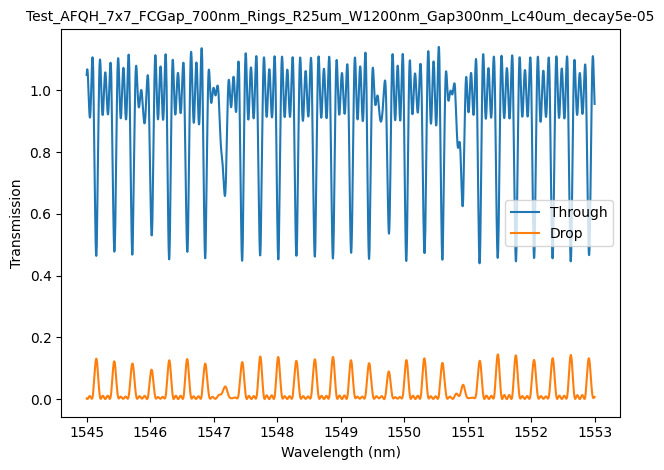

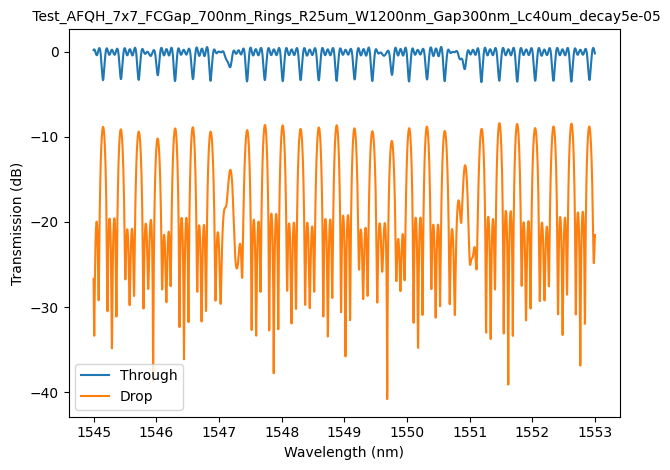

In [6]:

#------------------------------------------------------------
# Extract Results
#------------------------------------------------------------
try:
    T_TH = f.getresult("TH", "T")
    T_DR = f.getresult("DR", "T")

    Tx_Through = np.abs(T_TH["T"].flatten())
    Tx_Drop    = np.abs(T_DR["T"].flatten())
    Wavelength = T_TH["lambda"].flatten()
except Exception as e:
    print(f"  ⚠ SKIPPED | {e}")

Tx_Total = Tx_Through + Tx_Drop

idx_1550        = np.argmin(np.abs(Wavelength - 1548.533e-9))
loss_dB_1550    = -10 * np.log10(Tx_Total[idx_1550])

print(f"Loss={loss_dB_1550:.2f} dB")

#------------------------------------------------------------
# Plot
#------------------------------------------------------------
fig1 = plt.figure()
plt.plot(Wavelength*1e9, Tx_Through, label="Through")
plt.plot(Wavelength*1e9, Tx_Drop,    label="Drop")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Transmission")
plt.title(f"{tag}", fontsize=10)
plt.legend()
plt.tight_layout()
plt.savefig(DataDir / f"{fname}_lin.png", dpi=300, bbox_inches='tight')
# mplcursors.cursor(hover=True)
# disconnect_zoom = zoom_factory(plt.gca())
plt.show()


fig2 = plt.figure()
plt.plot(Wavelength*1e9, 10*np.log10(Tx_Through), label="Through")
plt.plot(Wavelength*1e9, 10*np.log10(Tx_Drop),    label="Drop")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Transmission (dB)")
plt.title(f" {tag}",fontsize=10)
plt.legend()
plt.tight_layout()
plt.savefig(DataDir / f"{fname}.png", dpi=300, bbox_inches='tight')
# mplcursors.cursor(hover=True)
# disconnect_zoom = zoom_factory(plt.gca())
plt.show()

In [7]:

#------------------------------------------------------------
# Save Data
#------------------------------------------------------------

meta = {
    "Width_nm"          : WgWidth  * 1e9,
    "Height_nm"         : Height * 1e9,
    "Radius_um"         : Radius * 1e6,
    "Gap_nm"            : Gap    * 1e9,
    "FCGap_nm"          : FCGap * 1e9, 
    "Lc_um"             : Lc * 1e6,
    "Material"          : Material,
    "Index"             : Index,
    "UseIndex"          : UseIndex,
    "Timestamp"         : time.strftime("%Y%m%d_%H%M%S"),
}

with open(fname, "w") as file:
    for k, v in meta.items():
        file.write(f"# {k}: {v}\n")
    file.write("# Wavelength_nm\tTx_Through\tTx_Drop\n")

data = np.column_stack([Wavelength*1e9, Tx_Through, Tx_Drop])
with open(fname, "ab") as file:
    np.savetxt(file, data, delimiter="\t")

print(f"Saved: {fname}")

Saved: D:\Ligentic_NU_1_TapeOut_April2026\scripts\FDTD_Results\Test_AFQH_7x7_FCGap_700nm_Rings_R25um_W1200nm_Gap300nm_Lc40um_decay5e-05.txt
